# Анализ данных

## Линейная регрессия

In [1]:
import pandas as pd
import numpy as np   
import matplotlib.pyplot as plt  
import seaborn as sns
from scipy import stats
import itertools
import math
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # масштабирование и кодирование переменных
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error  # метрики качества регрессии
from statsmodels.stats.outliers_influence import variance_inflation_factor  # диагностика мультиколлинеарности
from statsmodels.stats.stattools import durbin_watson  # проверка автокорреляции остатков
import statsmodels.api as sm  # регрессия для статистики и эконометрики
from sklearn.compose import ColumnTransformer  # преобразование переменных
from statsmodels.stats.diagnostic import het_breuschpagan  # проверка гетероскедастичности
import warnings
warnings.filterwarnings('ignore')

### [Текучесть кадров и производительность труда](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)

[Описание признаков](https://inseaddataanalytics.github.io/INSEADAnalytics/groupprojects/January2018FBL/IBM_Attrition_VSS.html)

| Имя признака                   | Описание признака                                     |
|------------------------|------------------------------------------------|
| Age                    | Numerical Value                                 |
| Attrition              | Employee leaving the company (0=no, 1=yes)     |
| BusinessTravel        | (1=No Travel, 2=Travel Frequently, 3=Travel Rarely) |
| DailyRate             | Numerical Value - Salary Level                  |
| Department             | (1=HR, 2=R&D, 3=Sales)                         |
| DistanceFromHome     | Numerical Value - THE DISTANCE FROM WORK TO HOME |
| Education              | Numerical Value                                 |
| EducationField        | (1=HR, 2=LIFE SCIENCES, 3=MARKETING, 4=MEDICAL SCIENCES, 5=OTHERS, 6=TECHNICAL) |
| EmployeeCount         | Numerical Value                                 |
| EmployeeNumber        | Numerical Value - EMPLOYEE ID                   |
| EnvironmentSatisfaction| Numerical Value - SATISFACTION WITH THE ENVIRONMENT |
| Gender                 | (1=FEMALE, 2=MALE)                             |
| HourlyRate| Numerical Value - HOURLY SALARY                 |
| JobInvolvement        | Numerical Value - JOB INVOLVEMENT                |
| JobLevel              | Numerical Value - LEVEL OF JOB                   |
| JobRole               | (1=HC REP, 2=HR, 3=LAB TECHNICIAN, 4=MANAGER, 5=MANAGING DIRECTOR, 6=RESEARCH DIRECTOR, 7=RESEARCH SCIENTIST, 8=SALES EXECUTIVE, 9=SALES REPRESENTATIVE) |
| JobSatisfaction       | Numerical Value - SATISFACTION WITH THE JOB     |
| MaritalStatus         | (1=DIVORCED, 2=MARRIED, 3=SINGLE)               |
| MonthlyIncome         | Numerical Value - MONTHLY SALARY                 |
| MonthlyRate            | Numerical Value - MONTHLY RATE                   |
| NumCompaniesWorked    | Numerical Value - NO. OF COMPANIES WORKED AT    |
| Over18                | (1=YES, 2=NO)                                   |
| OverTime               | (1=NO, 2=YES)                                   |
| PercentSalaryHike    | Numerical Value - PERCENTAGE INCREASE IN SALARY |
| PerformanceRating     | Numerical Value - PERFORMANCE RATING             |
| RelationshipSatisfaction | Numerical Value - RELATIONS SATISFACTION         |
| StandardHours         | Numerical Value - STANDARD HOURS                  |
| StockOptionLevel    | Numerical Value - STOCK OPTIONS                   |
| TotalWorkingYears    | Numerical Value - TOTAL YEARS WORKED              |
| TrainingTimesLastYear| Numerical Value - HOURS SPENT TRAINING           |
| WorkLifeBalance      | Numerical Value - TIME SPENT BETWEEN WORK AND OUTSIDE |
| YearsAtCompany       | Numerical Value - TOTAL NUMBER OF YEARS AT THE COMPANY |
| YearsInCurrentRole  | Numerical Value - YEARS IN CURRENT ROLE           |
| YearsSinceLastPromotion | Numerical Value - LAST PROMOTION               |
| YearsWithCurrManager  | Numerical Value - YEARS SPENT WITH CURRENT MANAGER |


In [2]:
df = pd.read_csv("Employee_Attrition.csv")
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Сгруппируем переменные по типам данных.

In [4]:
for t in df.dtypes.unique():
     print('Тип: {}\n{}\n'.format(t, df.dtypes[df.dtypes==t].index.values))

Тип: int64
['Age' 'DailyRate' 'DistanceFromHome' 'Education' 'EmployeeCount'
 'EmployeeNumber' 'EnvironmentSatisfaction' 'HourlyRate' 'JobInvolvement'
 'JobLevel' 'JobSatisfaction' 'MonthlyIncome' 'MonthlyRate'
 'NumCompaniesWorked' 'PercentSalaryHike' 'PerformanceRating'
 'RelationshipSatisfaction' 'StandardHours' 'StockOptionLevel'
 'TotalWorkingYears' 'TrainingTimesLastYear' 'WorkLifeBalance'
 'YearsAtCompany' 'YearsInCurrentRole' 'YearsSinceLastPromotion'
 'YearsWithCurrManager']

Тип: object
['Attrition' 'BusinessTravel' 'Department' 'EducationField' 'Gender'
 'JobRole' 'MaritalStatus' 'Over18' 'OverTime']



### Зависимая переменная: ежемесячная зарплата

In [5]:
df['MonthlyIncome'].describe()

count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64

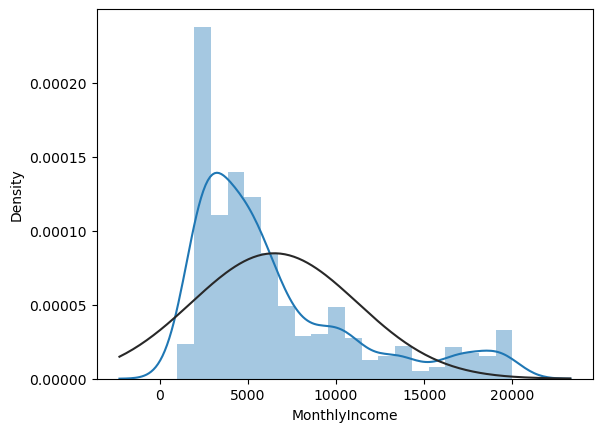

In [6]:
sns.distplot(df.MonthlyIncome, fit=stats.norm);

In [7]:
print('Асимметрия (Skewness): {:.4f}'.format(df['MonthlyIncome'].skew()))
print('Эксцесс (Kurtosis): {:.4f}'.format(df['MonthlyIncome'].kurt()))
print('Межквартильная широта: {:.4f}'.format((df['MonthlyIncome'].quantile(0.75) - df['MonthlyIncome'].quantile(0.25))/2))
print('Децильное отношение: {:.4f}'.format(df['MonthlyIncome'].quantile(0.9)/df['MonthlyIncome'].quantile(0.1)))

Асимметрия (Skewness): 1.3698
Эксцесс (Kurtosis): 1.0052
Межквартильная широта: 2734.0000
Децильное отношение: 5.9439


In [8]:
stats.kstest(df.MonthlyIncome, 'norm', args=(df.MonthlyIncome.mean(), df.MonthlyIncome.std()))

KstestResult(statistic=0.16892145497691968, pvalue=3.88275968028508e-37, statistic_location=5775, statistic_sign=1)

Зависимая переменная имеет распределение отличное от нормального. Оно асимметрично (сдвиг в сторону меньших значений) и характеризуется пиковостью. Среднее значение - 6502.9, стандартное отклонение довольно высокое - 4708.0. Медиана  - 4919, межквартильная широта - 2734, что также характеризует довольно большой разброс серединных 50% значений относительно медианы. Децильное отношение - 5.9 подтверждает сильную вариативность между крайними значениями. Тест Колмогорова-Смирнова (p < 0.05) подтверждает статистическое отклонение от нормальности. Для нормализации данных можно попробовать применить логарифмическое преобразование.

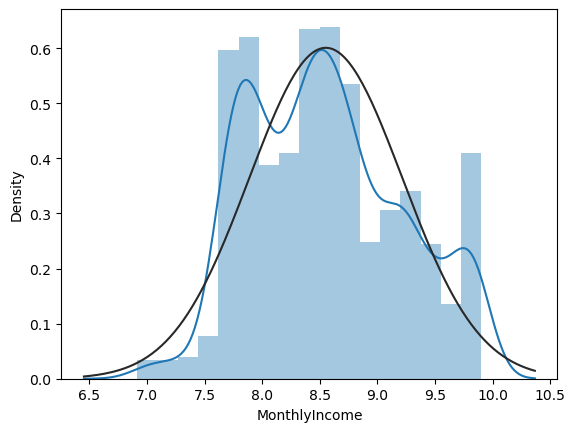

In [9]:
MonthlyIncome_log = np.log(df['MonthlyIncome'])  # натуральный логарифм
sns.distplot(MonthlyIncome_log, fit=stats.norm); 

Теперь распределение больше похоже на нормальное.

### Потенциальные предикторы

Рассмотрим какие предикторы могут влиять на зарплату.

**Карьерный путь и опыт**
- TotalWorkingYears
- YearsAtCompany
- YearsInCurrentRole
- YearsWithCurrManager
- YearsSinceLastPromotion
- NumCompaniesWorked

**Должность, уровень, отдел**
- JobLevel 
- JobRole
- Department

**Образование**
- Education
- EducationField

**Производительность и финансовое стимулирование**
- PerformanceRating
- PercentSalaryHike

**Рабочая нагрузка и обучение**
- OverTime
- BusinessTravel
- TrainingTimesLastYear

**Удовлетворенность, вовлеченность и баланс**
- EnvironmentSatisfaction
- BusinessTravel
- JobSatisfaction
- RelationshipSatisfaction
- JobInvolvement
- WorkLifeBalance

**Другое**
- DistanceFromHome
- StockOptionLevel

**Демография**
- Age
- Gender
- MaritalStatus

**ИСКЛЮЧАЕМ**

**Напрямую связаны с зарплатой и могут искусственно завысить качество модели**
- DailyRate
- HourlyRate
- MonthlyRate

**ID, константы, увольнение**
- EmployeeNumber (ID)
- EmployeeCount (константа)
- Over18 (константа)
- StandardHours (константа)
- Attrition (может быть следствием зарплаты, а не причиной)

Удаляем ненужные предикторы.

In [10]:
drop_cols = [
    "DailyRate",
    "HourlyRate",
    "MonthlyRate",
    "EmployeeNumber",
    "EmployeeCount",
    "StandardHours",
    "Over18",
    "Attrition"
]

df = df.drop(columns=drop_cols)

Разделяем предикторы и зависимую переменную.

In [11]:
X = df.drop(columns=["MonthlyIncome"])
y = df["MonthlyIncome"]

Определяем числовые и категориальные предикторы.

In [12]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Числовые:", numeric_features)
print("Категориальные:", categorical_features)

Числовые: Index(['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')
Категориальные: Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


### Числовые предикторы

Рассмотрим корреляцию между числовыми предикторами.

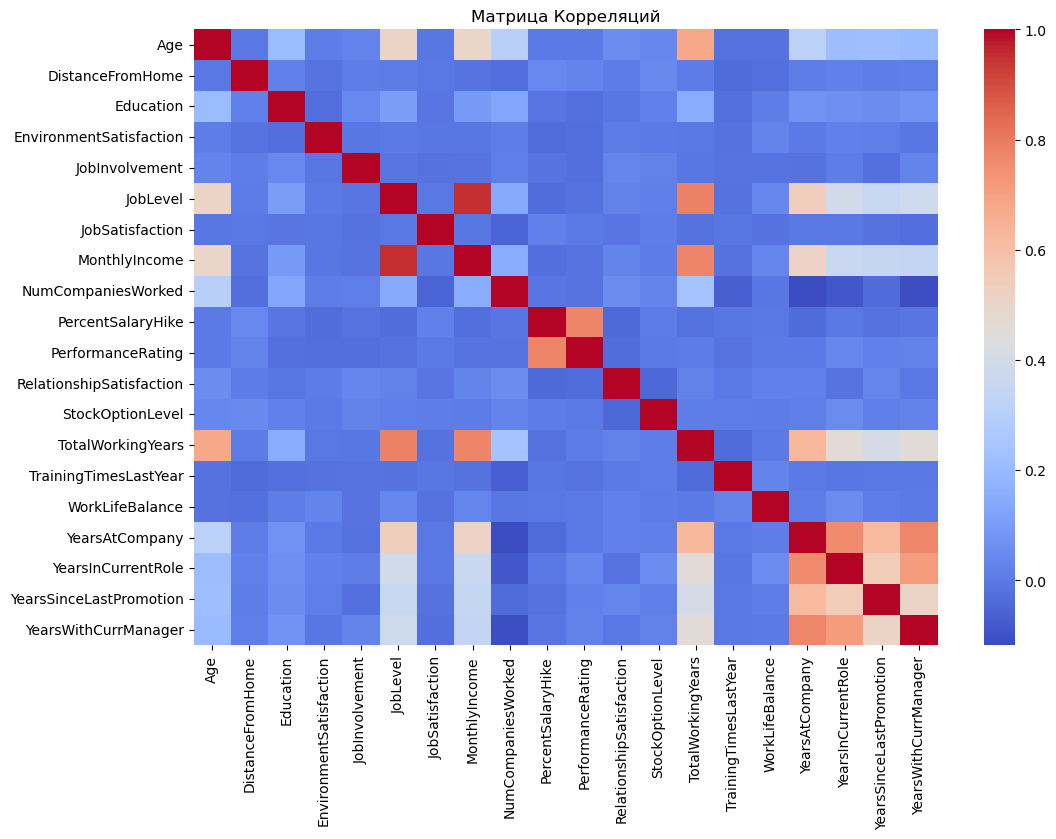

In [13]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")
plt.title("Матрица Корреляций")
plt.show()

Между некоторыми предикторами есть сильные корреляции, что может стать причиной мультиколлинеарности. Выведем предикторы, между которыми корреляция больше 0.65.

In [14]:
corr_matrix = df[numeric_features].corr()

pairs = []
for i, j in itertools.combinations(corr_matrix.columns, 2):
    corr = corr_matrix.loc[i, j]
    if abs(corr) > 0.65:
        pairs.append((i, j, corr))

for p in pairs:
    print(p)

('Age', 'TotalWorkingYears', 0.6803805357911985)
('JobLevel', 'TotalWorkingYears', 0.7822078045362748)
('PercentSalaryHike', 'PerformanceRating', 0.7735499964012664)
('YearsAtCompany', 'YearsInCurrentRole', 0.7587537366134619)
('YearsAtCompany', 'YearsWithCurrManager', 0.7692124251007031)
('YearsInCurrentRole', 'YearsWithCurrManager', 0.7143647616385931)


**Удалим:**
- JobLevel
- PercentSalaryHike
- YearsInCurrentRole
- YearsWithCurrManager
- Age

**Оставим:**
- TotalWorkingYears — более фундаментальный показатель опыта
- PerformanceRating — более интерпретируемая метрика производительности
- YearsAtCompany — базовая переменная стажа внутри компании

In [15]:
cols_to_drop = [
    'JobLevel',
    'PercentSalaryHike',
    'YearsInCurrentRole',
    'YearsWithCurrManager',
    'Age'
]

X = X.drop(columns=cols_to_drop)
numeric_features = [col for col in numeric_features if col not in cols_to_drop]

In [16]:
corr_matrix = df[numeric_features].corr()

pairs = []
for i, j in itertools.combinations(corr_matrix.columns, 2):
    corr = corr_matrix.loc[i, j]
    if abs(corr) > 0.65:
        pairs.append((i, j, corr))

for p in pairs:
    print(p)

Теперь между предикторами нет корреляций больше 0.65.

Проверим VIF.

In [17]:
vif = pd.DataFrame()
vif["feature"] = df[numeric_features].columns
vif["VIF"] = [variance_inflation_factor(df[numeric_features].values, i) for i in range(df[numeric_features].shape[1])]

vif = vif.sort_values(by="VIF", ascending=False).reset_index(drop=True)
print(vif)

                     feature        VIF
0          PerformanceRating  34.771633
1            WorkLifeBalance  14.770186
2             JobInvolvement  14.096601
3                  Education   8.952835
4   RelationshipSatisfaction   7.044253
5    EnvironmentSatisfaction   6.848371
6            JobSatisfaction   6.793172
7          TotalWorkingYears   6.177197
8             YearsAtCompany   5.773965
9      TrainingTimesLastYear   5.525747
10        NumCompaniesWorked   2.661353
11   YearsSinceLastPromotion   2.374852
12          DistanceFromHome   2.286939
13          StockOptionLevel   1.875666


VIF больше 10 у 3-ех предикторов. То есть некоторые предикторы почти линейно объясняются другими, хотя высоких парных корреляций не осталось.

Посмотрим как эти три предиктора коррелируют с зарплатой.

In [18]:
corr = df[['PerformanceRating', 'WorkLifeBalance', 'JobInvolvement', 'MonthlyIncome']].corr()
print(corr['MonthlyIncome'].drop('MonthlyIncome'))

PerformanceRating   -0.017120
WorkLifeBalance      0.030683
JobInvolvement      -0.015271
Name: MonthlyIncome, dtype: float64


Корреляции почти нулевые, можно предикторы удалить.

In [19]:
cols_to_drop = [
    'PerformanceRating', 
    'WorkLifeBalance', 
    'JobInvolvement'
]

X = X.drop(columns=cols_to_drop)
numeric_features = [col for col in numeric_features if col not in cols_to_drop]

In [20]:
vif = pd.DataFrame()
vif["feature"] = df[numeric_features].columns
vif["VIF"] = [variance_inflation_factor(df[numeric_features].values, i) for i in range(df[numeric_features].shape[1])]

vif = vif.sort_values(by="VIF", ascending=False).reset_index(drop=True)
print(vif)

                     feature       VIF
0                  Education  7.570109
1          TotalWorkingYears  6.158279
2   RelationshipSatisfaction  6.138471
3    EnvironmentSatisfaction  5.915438
4            JobSatisfaction  5.863329
5             YearsAtCompany  5.747807
6      TrainingTimesLastYear  4.887818
7         NumCompaniesWorked  2.634434
8    YearsSinceLastPromotion  2.372549
9           DistanceFromHome  2.215580
10          StockOptionLevel  1.846105


Больше нет проблемы мультиколлинеарности, работа с подготовкой числовых предикторов завершена.

### Категориальные предикторы

Выведем частотные таблицы.

In [21]:
for col in categorical_features:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False)) 
    print("\n")

--- BusinessTravel ---
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: BusinessTravel, dtype: int64


--- Department ---
Research & Development    961
Sales                     446
Human Resources            63
Name: Department, dtype: int64


--- EducationField ---
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: EducationField, dtype: int64


--- Gender ---
Male      882
Female    588
Name: Gender, dtype: int64


--- JobRole ---
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: JobRole, dtype: int64


--- MaritalStatus ---
Married     673
Single      470
Divorced    327
Name: MaritalStatus, dtype: int

По категориальным предикторам все группы достаточно наполнены. Объединять или удалять группы не стоит. 

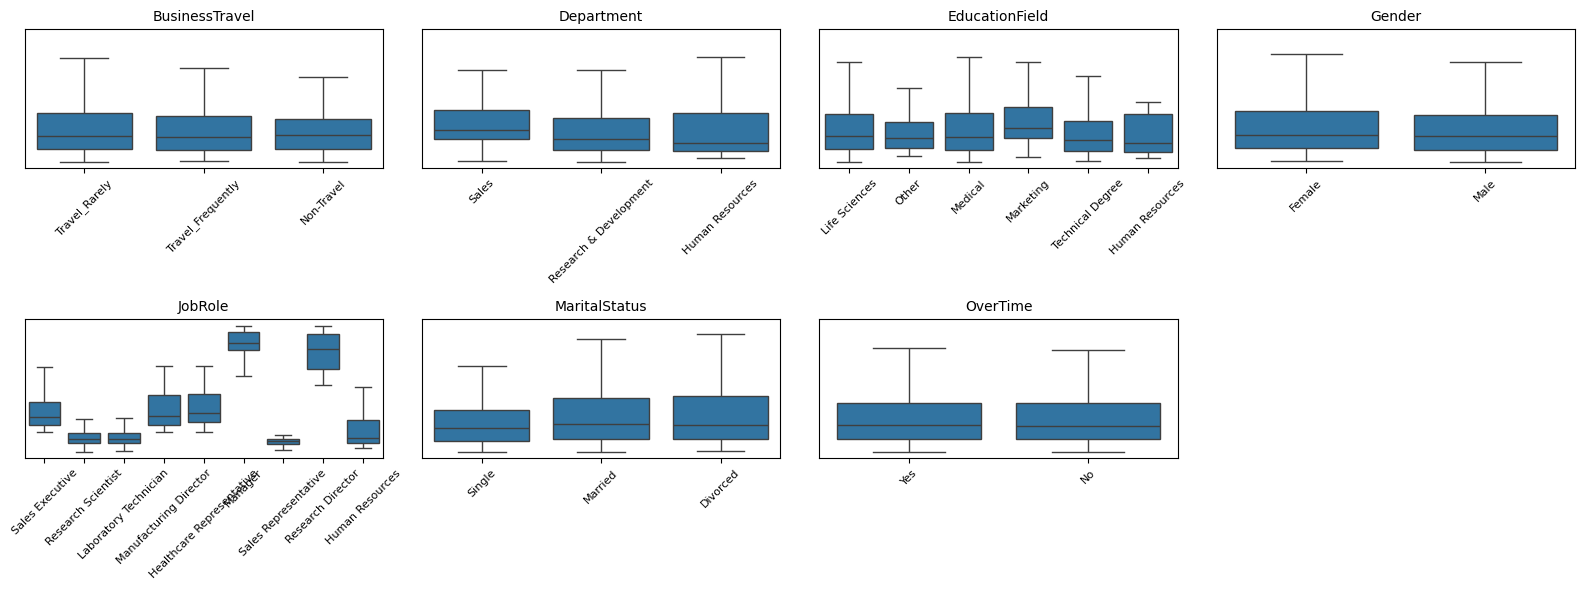

In [22]:
n_cols = math.ceil(len(categorical_features) / 2)
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 6), sharey=True)
axes = axes.flatten()

for ax, cat in zip(axes, categorical_features):
    sns.boxplot(x=cat, y=y, data=df, ax=ax, showfliers=False) 
    ax.set_title(cat, fontsize=10)  
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', left=False, labelleft=False)

for i in range(len(categorical_features), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

На графиках видны отличия зарплаты по некоторым категориям.

Используем One-Hot Encoding для кодирования категориальных предикторов.

`drop="first"` убирает первый бинарный столбец при one-hot кодировании. Это нужно, чтобы избежать мультиколлинеарности (dummy trap).

In [23]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
    ],
    remainder="passthrough"
)

X_processed = preprocessor.fit_transform(X)

ohe_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)

feature_names = list(ohe_features) + list(numeric_features)

X_processed = pd.DataFrame(X_processed, columns=feature_names, index=X.index)

X_processed = sm.add_constant(X_processed)

model = sm.OLS(y, X_processed).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          MonthlyIncome   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                     325.5
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:22:31   Log-Likelihood:                -12966.
No. Observations:                1470   AIC:                         2.600e+04
Df Residuals:                    1437   BIC:                         2.617e+04
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

In [24]:
y_pred = model.predict(X_processed)

mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)

MSE: 2685557.782479877
MAE: 1287.2190629339343
RMSE: 1638.7671532221646


Визуализируем предсказания.

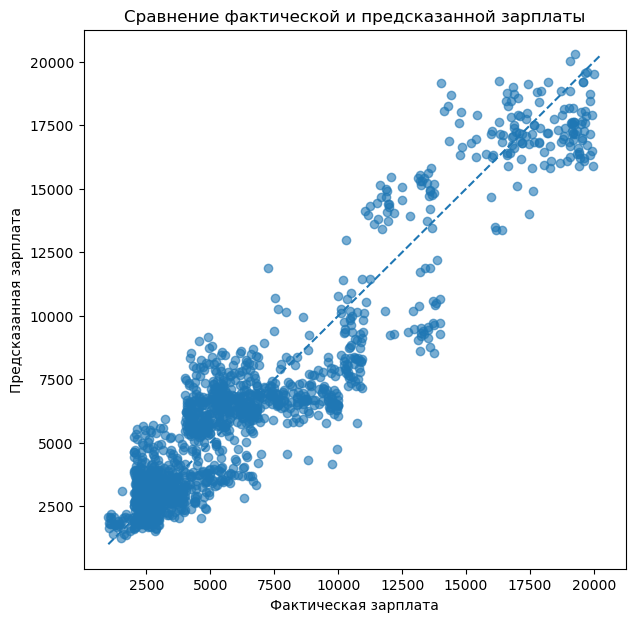

In [25]:
y_pred = model.predict(X_processed)

plt.figure(figsize=(7,7))

plt.scatter(y, y_pred, alpha=0.6)

min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Фактическая зарплата")
plt.ylabel("Предсказанная зарплата")
plt.title("Сравнение фактической и предсказанной зарплаты")

plt.show()

Высокая корреляция предсказаний с фактическими зарплатами.

Топ-10 факторов увеличения зарплаты.

In [26]:
coef = model.params

coef = coef.drop("const")

top10 = coef.sort_values(ascending=False).head(10)

print(top10)

JobRole_Manager                     7762.638447
JobRole_Research Director           7114.187111
JobRole_Sales Executive              554.058068
BusinessTravel_Travel_Frequently     258.157757
BusinessTravel_Travel_Rarely         211.885000
TotalWorkingYears                    188.903664
Gender_Male                          170.571630
OverTime_Yes                          79.488654
MaritalStatus_Single                  58.553536
JobRole_Manufacturing Director        54.023706
dtype: float64


Топ-10 факторов снижения зарплаты.

In [27]:
coef = model.params

coef = coef.drop("const")

bottom10 = coef.sort_values(ascending=True).head(10)

print(bottom10)

JobRole_Research Scientist        -3026.409335
JobRole_Laboratory Technician     -3006.174614
JobRole_Sales Representative      -2468.207680
JobRole_Human Resources           -2250.324720
Department_Sales                   -667.119242
EducationField_Medical             -305.669255
EducationField_Life Sciences       -184.901569
EducationField_Other               -142.180963
EducationField_Technical Degree     -79.367446
EducationField_Marketing            -65.379491
dtype: float64


Не все предикторы оказывают статистически значимое влияние на зарплату. Значимыми являются предикторы, коэффициенты которых имеют p-value < 0.05.

Если цель исследования - выявить исключительно те факторы, которые  реально влияют на зарплату, то незначимые коэффициенты лучше убрать.

Если цель - предсказание, то незначимые коэффициенты можно оставить, особенно если модель построена для максимального качества предсказаний, а не интерпретации.


Выведем референтные группы для категориальных предикторов.

In [28]:
for col in categorical_features:
    categories = df[col].unique()
    ref = sorted(categories)[0]  
    print(f"Предиктор: {col}, референтная группа: {ref}")

Предиктор: BusinessTravel, референтная группа: Non-Travel
Предиктор: Department, референтная группа: Human Resources
Предиктор: EducationField, референтная группа: Human Resources
Предиктор: Gender, референтная группа: Female
Предиктор: JobRole, референтная группа: Healthcare Representative
Предиктор: MaritalStatus, референтная группа: Divorced
Предиктор: OverTime, референтная группа: No


### Интерпретация коэффициентов

- Каждый дополнительный год общего стажа работы (TotalWorkingYears) увеличивает ожидаемую зарплату примерно на 183.8 единицы, при прочих равных условиях. То есть, если сотрудник имеет на 1 год больше опыта, модель ожидает, что его зарплата будет выше примерно на 183.8 единиц.
- Сотрудник с должностью Manager в среднем зарабатывает на 7762.7 единиц больше, чем сотрудник с должностью Healthcare Representative (референтная группа), при прочих равных условиях.

_Далее интерпретируйте остальные коэффициенты модели..._

Чтобы можно было сравнить предикторы по степени влияния на зависимую переменную, нужно стандартизировать значения всех переменных в модели.

In [29]:
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_processed.drop(columns="const"))

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X_processed.drop(columns="const").columns,
    index=X_processed.index
)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1)).flatten()

X_scaled = sm.add_constant(X_scaled)

model_std = sm.OLS(y_scaled, X_scaled).fit()

print(model_std.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                     325.5
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:22:35   Log-Likelihood:                -535.03
No. Observations:                1470   AIC:                             1136.
Df Residuals:                    1437   BIC:                             1311.
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

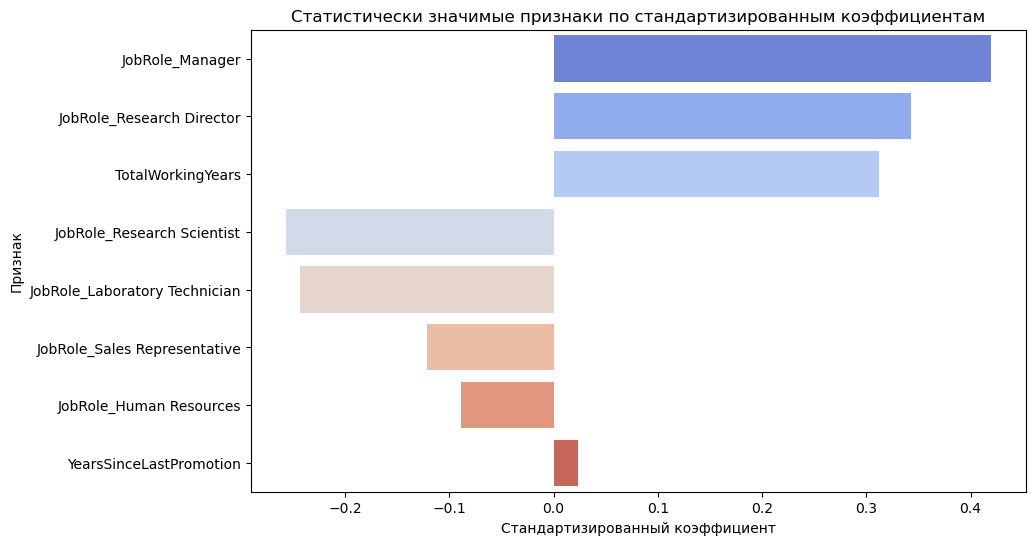

In [30]:
results_df = pd.DataFrame({
    "feature": model_std.params.index,
    "coef": model_std.params.values,
    "p_value": model_std.pvalues
})

# убираем константу и оставляем только значимые признаки
results_no_const = results_df[
    (results_df['feature'] != 'const') & 
    (results_df['p_value'] < 0.05)
]

results_no_const = results_no_const.reindex(
    results_no_const['coef'].abs().sort_values(ascending=False).index
)

plt.figure(figsize=(10,6))
sns.barplot(
    x='coef',
    y='feature',
    data=results_no_const,
    palette='coolwarm'
)
plt.title("Статистически значимые признаки по стандартизированным коэффициентам")
plt.xlabel("Стандартизированный коэффициент")
plt.ylabel("Признак")
plt.show()

Проверим остатки.

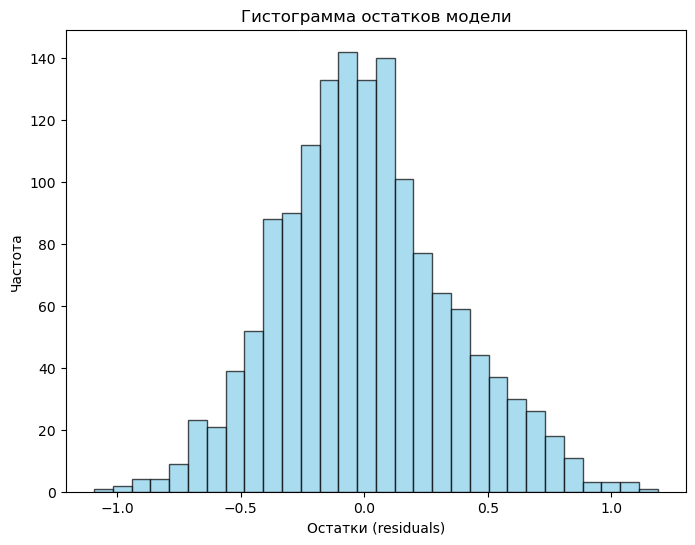

In [31]:
y_pred = model_std.predict(X_scaled)

residuals = y_scaled - y_pred

plt.figure(figsize=(8,6))
plt.hist(residuals, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel("Остатки (residuals)")
plt.ylabel("Частота")
plt.title("Гистограмма остатков модели")
plt.show()

Остатки имеют нормальное распределение.

Построим график зависимости остатков и предсказанных значений.

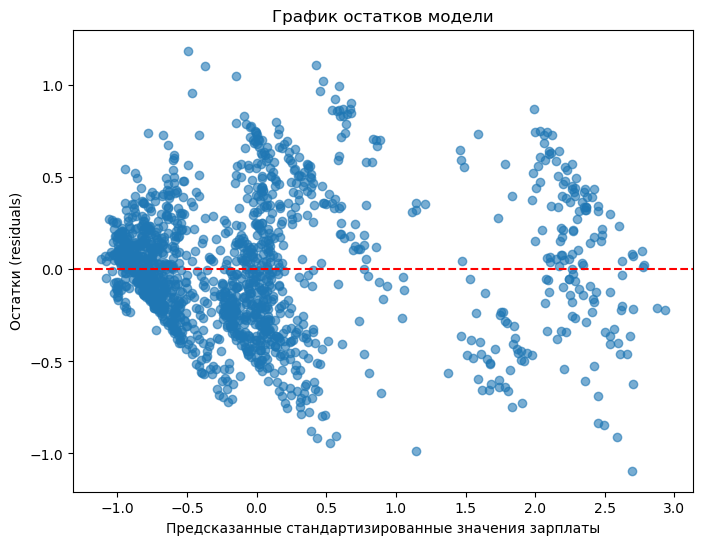

In [32]:
y_pred = model_std.predict(X_scaled)

residuals = y_scaled - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Предсказанные стандартизированные значения зарплаты")
plt.ylabel("Остатки (residuals)")
plt.title("График остатков модели")
plt.show()

Нет тренда по предсказанным значениям → гомоскедастичность.

Проверим мультиколлинеарность

In [33]:
X_vif = X_scaled.drop(columns="const")

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) 
                   for i in range(X_vif.shape[1])]

vif_data = vif_data.sort_values("VIF", ascending=False)

print(vif_data)

                              feature        VIF
2   Department_Research & Development  43.629706
3                    Department_Sales  43.495765
4        EducationField_Life Sciences  23.901329
6              EducationField_Medical  21.459198
16            JobRole_Sales Executive  14.598705
5            EducationField_Marketing  10.795000
8     EducationField_Technical Degree   8.781287
10            JobRole_Human Resources   7.118152
7                EducationField_Other   5.992954
17       JobRole_Sales Representative   5.436146
19               MaritalStatus_Single   3.015178
15         JobRole_Research Scientist   2.796972
28                  TotalWorkingYears   2.796931
12                    JobRole_Manager   2.687189
11      JobRole_Laboratory Technician   2.649038
30                     YearsAtCompany   2.545800
1        BusinessTravel_Travel_Rarely   2.358913
0    BusinessTravel_Travel_Frequently   2.351687
13     JobRole_Manufacturing Director   1.918357
27                  

VIF > 10 → сильная мультиколлинеарность между дамми-переменными. Можно предположить, что образование связано с работой в определенных департаментах и на определенных ролях. Возможно, стоит удалить признак образование.

Выведем выбросы.

In [34]:
standard_resid = (residuals - np.mean(residuals)) / np.std(residuals)
outlier_values = standard_resid[np.abs(standard_resid) > 3]

print("Значения стандартизированных остатков больше 3 по модулю:")
print(outlier_values)

Значения стандартизированных остатков больше 3 по модулю:
189     3.180377
440     3.173900
510     3.008775
962    -3.141039
1243    3.410094
dtype: float64


Есть один объект, но значение стандартизированного остатка не слишком высокое. Можно сделать вывод, что нет явной проблемы наличия выбросов.

Выведем влияющие наблюдения.

In [35]:
influence = model_std.get_influence()

influence_df = pd.DataFrame({
    'leverage': influence.hat_matrix_diag,
    'dffits': influence.dffits[0],
    'cooks_distance': influence.cooks_distance[0]
}, index=X_scaled.index)

n, k = X_scaled.shape  
mean_leverage = k / n
dffits_threshold = 2 * np.sqrt(k / n)
cooks_threshold = 1

# потенциально опасные наблюдения
very_dangerous = influence_df[
    (influence_df['cooks_distance'] > cooks_threshold) &
    (influence_df['leverage'] > 3 * mean_leverage) &
    (np.abs(influence_df['dffits']) > dffits_threshold)
]

count_very_dangerous = very_dangerous.shape[0]
print(f"Количество потенциально опасных наблюдений: {count_very_dangerous}")

print("Индексы опасных наблюдений:", very_dangerous.index.tolist())

Количество потенциально опасных наблюдений: 0
Индексы опасных наблюдений: []


Отбираем потенциально опасные влияющие наблюдения по трём строгим критериям: 
- Cook's distance > 1 (наблюдение сильно влияет на все коэффициенты модели), 
- leverage > 3 средних значений (наблюдение резко выделяется по комбинации признаков),
- |DFFITS| > 2√((k+1)/n) (наблюдение существенно меняет свои предсказания при исключении из модели).

Все три условия вместе гарантируют, что выбранные точки действительно могут сильно исказить модель и требуют особого внимания.

Опасных влияющих наблюдений нет.

Проверим автокорреляцию ошибок.

In [36]:
dw = durbin_watson(residuals)
print(f"Durbin-Watson: {dw:.2f}")

Durbin-Watson: 2.02


Значение близко к 2, следовательно у ошибок нет автокорреляции.

Возможные улучшения модели:
- логарифмировать зарплату,
- устранить мультиколлинеарность категориальных признаков,
- добавить эффекты взаимодействия.

Можно провести улучшение модели. Прологарифмировать зависимую переменную, устранить мультиколлинеарность категориальных предикторов, удалить статистически незначимые предикторы, добавить эффекты взаимодействия.